In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../outputs/featured_data.csv')

In [2]:
feature_cols = [
    'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
    'Item_MRP', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type',
    'Outlet_Age', 'Item_Category'
]
target_col = 'Item_Outlet_Sales'

df_model = df[feature_cols + [target_col]].copy()
print("Model data shape:", df_model.shape)

Model data shape: (8523, 11)


In [3]:
le = LabelEncoder()
cat_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 
            'Outlet_Location_Type', 'Outlet_Type', 'Item_Category']

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("After encoding:")
print(df_model.dtypes)

After encoding:
Item_Weight             float64
Item_Fat_Content          int64
Item_Visibility         float64
Item_Type                 int64
Item_MRP                float64
Outlet_Size               int64
Outlet_Location_Type      int64
Outlet_Type               int64
Outlet_Age                int64
Item_Category             int64
Item_Outlet_Sales       float64
dtype: object


In [4]:
X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 6818 rows
Test set: 1705 rows


In [5]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("=== LINEAR REGRESSION RESULTS ===")
print(f"RMSE: {lr_rmse:.2f}")
print(f"MAE:  {lr_mae:.2f}")
print(f"R²:   {lr_r2:.4f}")

=== LINEAR REGRESSION RESULTS ===
RMSE: 1143.10
MAE:  856.49
R²:   0.5192


In [6]:
rf_model = RandomForestRegressor(
    n_estimators=100,      # 100 decision trees
    max_depth=10,          # Max depth per tree
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("=== RANDOM FOREST RESULTS ===")
print(f"RMSE: {rf_rmse:.2f}")
print(f"MAE:  {rf_mae:.2f}")
print(f"R²:   {rf_r2:.4f}")

=== RANDOM FOREST RESULTS ===
RMSE: 1038.13
MAE:  726.32
R²:   0.6035


In [7]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [lr_rmse, rf_rmse],
    'MAE': [lr_mae, rf_mae],
    'R²': [lr_r2, rf_r2]
})
print("\n=== MODEL COMPARISON ===")
print(comparison.to_string(index=False))
comparison.to_csv('../outputs/model_results.csv', index=False)


=== MODEL COMPARISON ===
            Model        RMSE        MAE       R²
Linear Regression 1143.101160 856.491201 0.519244
    Random Forest 1038.130465 726.324254 0.603485


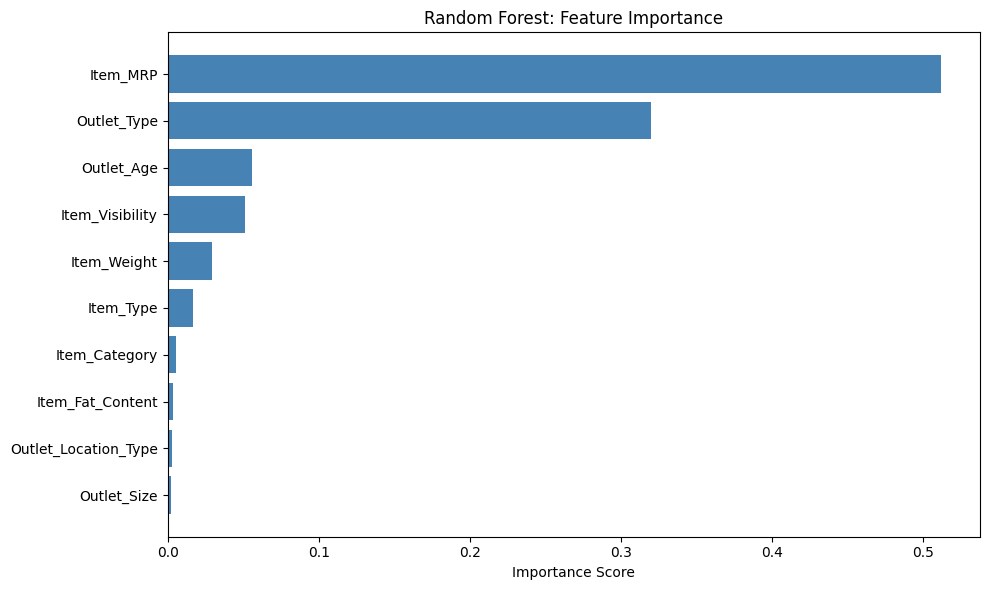

                Feature  Importance
4              Item_MRP    0.511856
7           Outlet_Type    0.320067
8            Outlet_Age    0.056153
2       Item_Visibility    0.050945
0           Item_Weight    0.029659
3             Item_Type    0.016657
9         Item_Category    0.005646
1      Item_Fat_Content    0.003705
6  Outlet_Location_Type    0.002767
5           Outlet_Size    0.002544


In [12]:
feat_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_importance['Feature'], feat_importance['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Random Forest: Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150)
plt.show()
print(feat_importance)


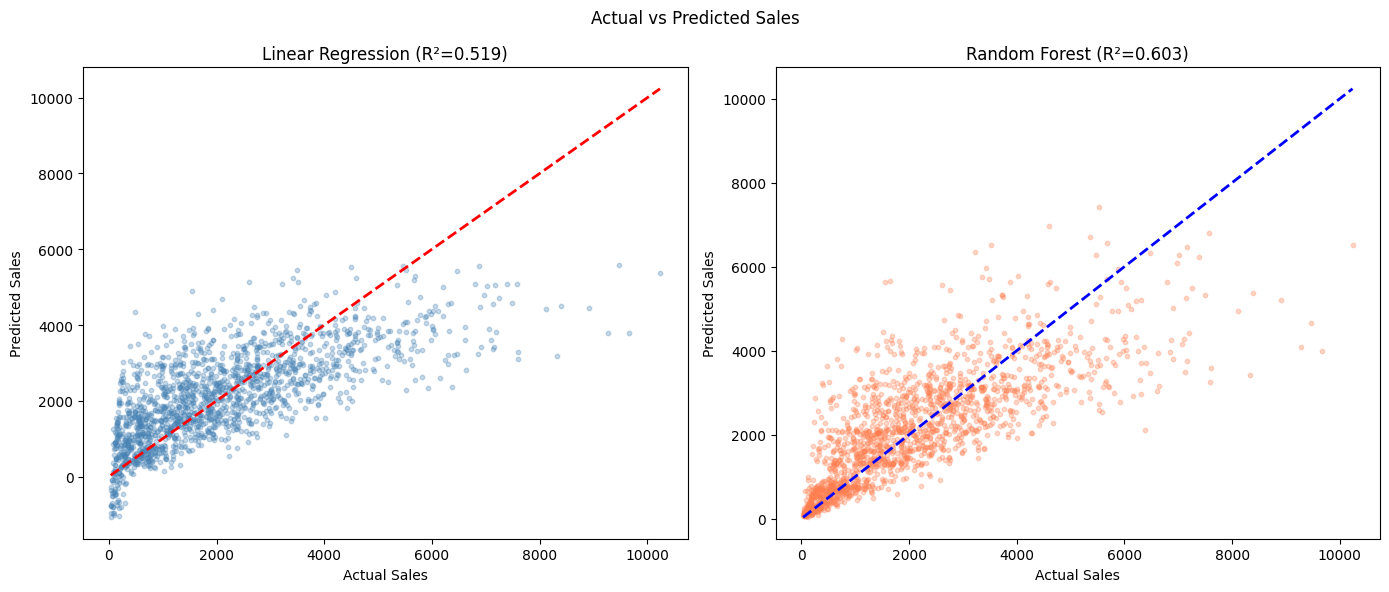

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.3, color='steelblue', s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'Linear Regression (R²={lr_r2:.3f})')
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')

# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.3, color='coral', s=10)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', lw=2)
axes[1].set_title(f'Random Forest (R²={rf_r2:.3f})')
axes[1].set_xlabel('Actual Sales')
axes[1].set_ylabel('Predicted Sales')

plt.suptitle('Actual vs Predicted Sales')
plt.tight_layout()
plt.savefig('../outputs/actual_vs_predicted.png', dpi=150)
plt.show()